# Пример загрузки baseline модели получение mIoU на валидационном датасете

## Хедеры и константы

In [1]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from pycocotools.coco import COCO
import numpy as np
from PIL import Image as PILImage
from torchvision.transforms import v2 as tr
from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

In [2]:
ROOT_DATASET = "./dataset_coco"
CKPT_PATH = "./weights/checkpoint_coco_fp16.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IGNORE_INDEX = 255

NUM_CLASSES = 81
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 4
BATCH_SIZE = 16

## Загрузка валидационного датасета (Один раз)

In [3]:
ROOT = Path(ROOT_DATASET)
ROOT.mkdir(parents=True, exist_ok=True)

urls = {
    # "train2017.zip": "http://images.cocodataset.org/zips/train2017.zip",
    "val2017.zip": "http://images.cocodataset.org/zips/val2017.zip",
    "annotations_trainval2017.zip": "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
}

def download(url, dst):
    if dst.exists():
        print(f"[skip] {dst.name} already exists")
        return
    print(f"[download] {dst.name}")
    urlretrieve(url, dst)
    print(f"[ok] {dst.name}")

def extract(zip_path, out_dir):
    marker = out_dir / (zip_path.stem.replace(".zip", ""))
    print(f"[extract] {zip_path.name}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
    print(f"[ok] extracted {zip_path.name}")

In [4]:
# Это нужно запустить один раз!!!

# for name, url in urls.items():
#     zip_path = ROOT / name
#     download(url, zip_path)
#     extract(zip_path, ROOT)

# print("Done. Check structure:")
# for p in [
#     # ROOT / "train2017",
#     ROOT / "val2017",
#     # ROOT / "annotations" / "instances_train2017.json",
#     ROOT / "annotations" / "instances_val2017.json",
# ]:
#     print(p, "->", p.exists())

In [5]:
def build_coco_semantic_masks(
    root=ROOT_DATASET,
    split="train2017",
    out_dir_name="semantic_masks",
    ignore_index=255,
    skip_crowd=True,
):
    """
    Создает PNG-маски semantic segmentation для COCO split.
    Маска: 0=background, 1..80=классы COCO (плотная перенумерация), 255=ignore (crowd).
    """
    root = Path(root)
    ann_file = root / "annotations" / f"instances_{split}.json"
    images_dir = root / split
    masks_dir = root / out_dir_name / split
    masks_dir.mkdir(parents=True, exist_ok=True)

    coco = COCO(str(ann_file))
    image_ids = sorted(coco.getImgIds())

    # cat_id -> train_id (1..N), 0 оставляем background
    cat_ids = sorted(coco.getCatIds())
    cat_id_to_train_id = {cat_id: i + 1 for i, cat_id in enumerate(cat_ids)}

    # сохранить mapping для повторного использования
    mapping_path = root / out_dir_name / "cat_id_to_train_id.npy"
    np.save(mapping_path, cat_id_to_train_id, allow_pickle=True)

    for image_id in tqdm(image_ids, desc=f"Building masks {split}"):
        img_info = coco.loadImgs(image_id)[0]
        h, w = img_info["height"], img_info["width"]
        out_path = masks_dir / (Path(img_info["file_name"]).stem + ".png")

        # если маска уже есть, можно пропустить
        if out_path.exists():
            continue

        mask = np.zeros((h, w), dtype=np.uint8)

        ann_ids = coco.getAnnIds(imgIds=image_id, iscrowd=None)
        anns = coco.loadAnns(ann_ids)
        anns = sorted(anns, key=lambda a: a.get("area", 0), reverse=True)

        for ann in anns:
            m = coco.annToMask(ann).astype(bool)

            if ann.get("iscrowd", 0) == 1:
                if skip_crowd:
                    mask[m] = ignore_index
                continue

            train_id = cat_id_to_train_id[ann["category_id"]]  # 1..80
            mask[m] = train_id

        PILImage.fromarray(mask, mode="L").save(out_path)

    print(f"[OK] {split}: masks in {masks_dir}")

In [6]:
# Это нужно запустить один раз!!!

# build_coco_semantic_masks(root=ROOT_DATASET, split="val2017")

## Загрузка модели

In [7]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

baseline = model.half() # fp16
# baseline = model.bfloat16() # bf16

state = torch.load(CKPT_PATH, map_location="cpu")
baseline.load_state_dict(state, strict=True)

baseline = baseline.to(DEVICE).eval()

## Формирование датасета

In [8]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):

        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.joint_prepare = tr.Compose([
                tr.RandomResizedCrop(
                    size,
                    scale=(0.6, 1.0),
                    interpolation=InterpolationMode.BILINEAR,
                    antialias=True
                ),
                tr.RandomHorizontalFlip(p=0.5),
            ])
        else:
            self.joint_prepare = tr.Compose([
                tr.Resize(size, interpolation=InterpolationMode.BILINEAR, antialias=True),
            ])

        if train:
            self.image_prepare = tr.Compose([
                tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])
        else:
            self.image_prepare = tr.Compose([
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))  # без np.array

        image, mask = self.joint_prepare(image, mask)
        image = self.image_prepare(image)
        return image, mask.long()

In [9]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [10]:
val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=0.19s)
creating index...
index created!


In [11]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [12]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    timeout= 60,
)

## Получение примеров предсказаний

Вспомогательные функции

In [13]:
def _build_seg_cmap_with_ignore(num_classes: int, ignore_color=(0.15, 0.15, 0.15, 1.0)):
    hues = (np.arange(num_classes) * 0.61803398875) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 1.0)
        colors.append((r, g, b, 1.0))

    colors.append(ignore_color)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5, 1), cmap.N)
    return cmap, norm

def _mask_boundaries(m: np.ndarray) -> np.ndarray:
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] != m[1:, :])
    b[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return b

def _boundary_rgba(mask: np.ndarray, color=(1.0, 1.0, 1.0, 1.0)):
    bd = _mask_boundaries(mask)
    overlay = np.zeros((*bd.shape, 4), dtype=np.float32)
    overlay[bd] = color
    return overlay

In [14]:
def show_val_predictions_triplets(
    model,
    val_ds,
    device,
    n_samples: int = 4,
    seed: int = 42,
    ignore_index: int = IGNORE_INDEX,
    max_legend_classes: int = 10,
):
    model.eval()
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    param_dtype = next(model.parameters()).dtype

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, true_mask = val_ds[idx]
            x = image.unsqueeze(0).to(device, non_blocking=True)

            if param_dtype in (torch.float16, torch.bfloat16):
                x = x.to(dtype=param_dtype)

            logits = model(x)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

            img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            true_show = true_mask.cpu().numpy().copy()
            true_show[true_show == ignore_index] = ignore_show_id

            axes[i, 0].imshow(img_show)
            axes[i, 0].set_title(f"image #{idx}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
            axes[i, 1].set_title("true_mask_val")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
            axes[i, 2].set_title("pred_mask")
            axes[i, 2].axis("off")

            # Легенда только по классам этой тройки
            ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
            order = np.argsort(-counts)
            ids = ids[order]

            shown = ids[:max_legend_classes]
            handles = []
            for cid in shown:
                cid = int(cid)
                if cid == ignore_show_id:
                    label = "255: ignore"
                else:
                    label = f"{cid}: {val_ds.class_names[cid]}"
                handles.append(Patch(facecolor=cmap(cid), edgecolor="none", label=label))                

            axes[i, 3].axis("off")
            axes[i, 3].legend(handles=handles, loc="upper left", frameon=False, fontsize=8, handlelength=1.0)
            extra = len(ids) - len(shown)
            axes[i, 3].set_title(f"classes in sample{f' (+{extra} more)' if extra > 0 else ''}", fontsize=9)

    plt.tight_layout()
    plt.show()


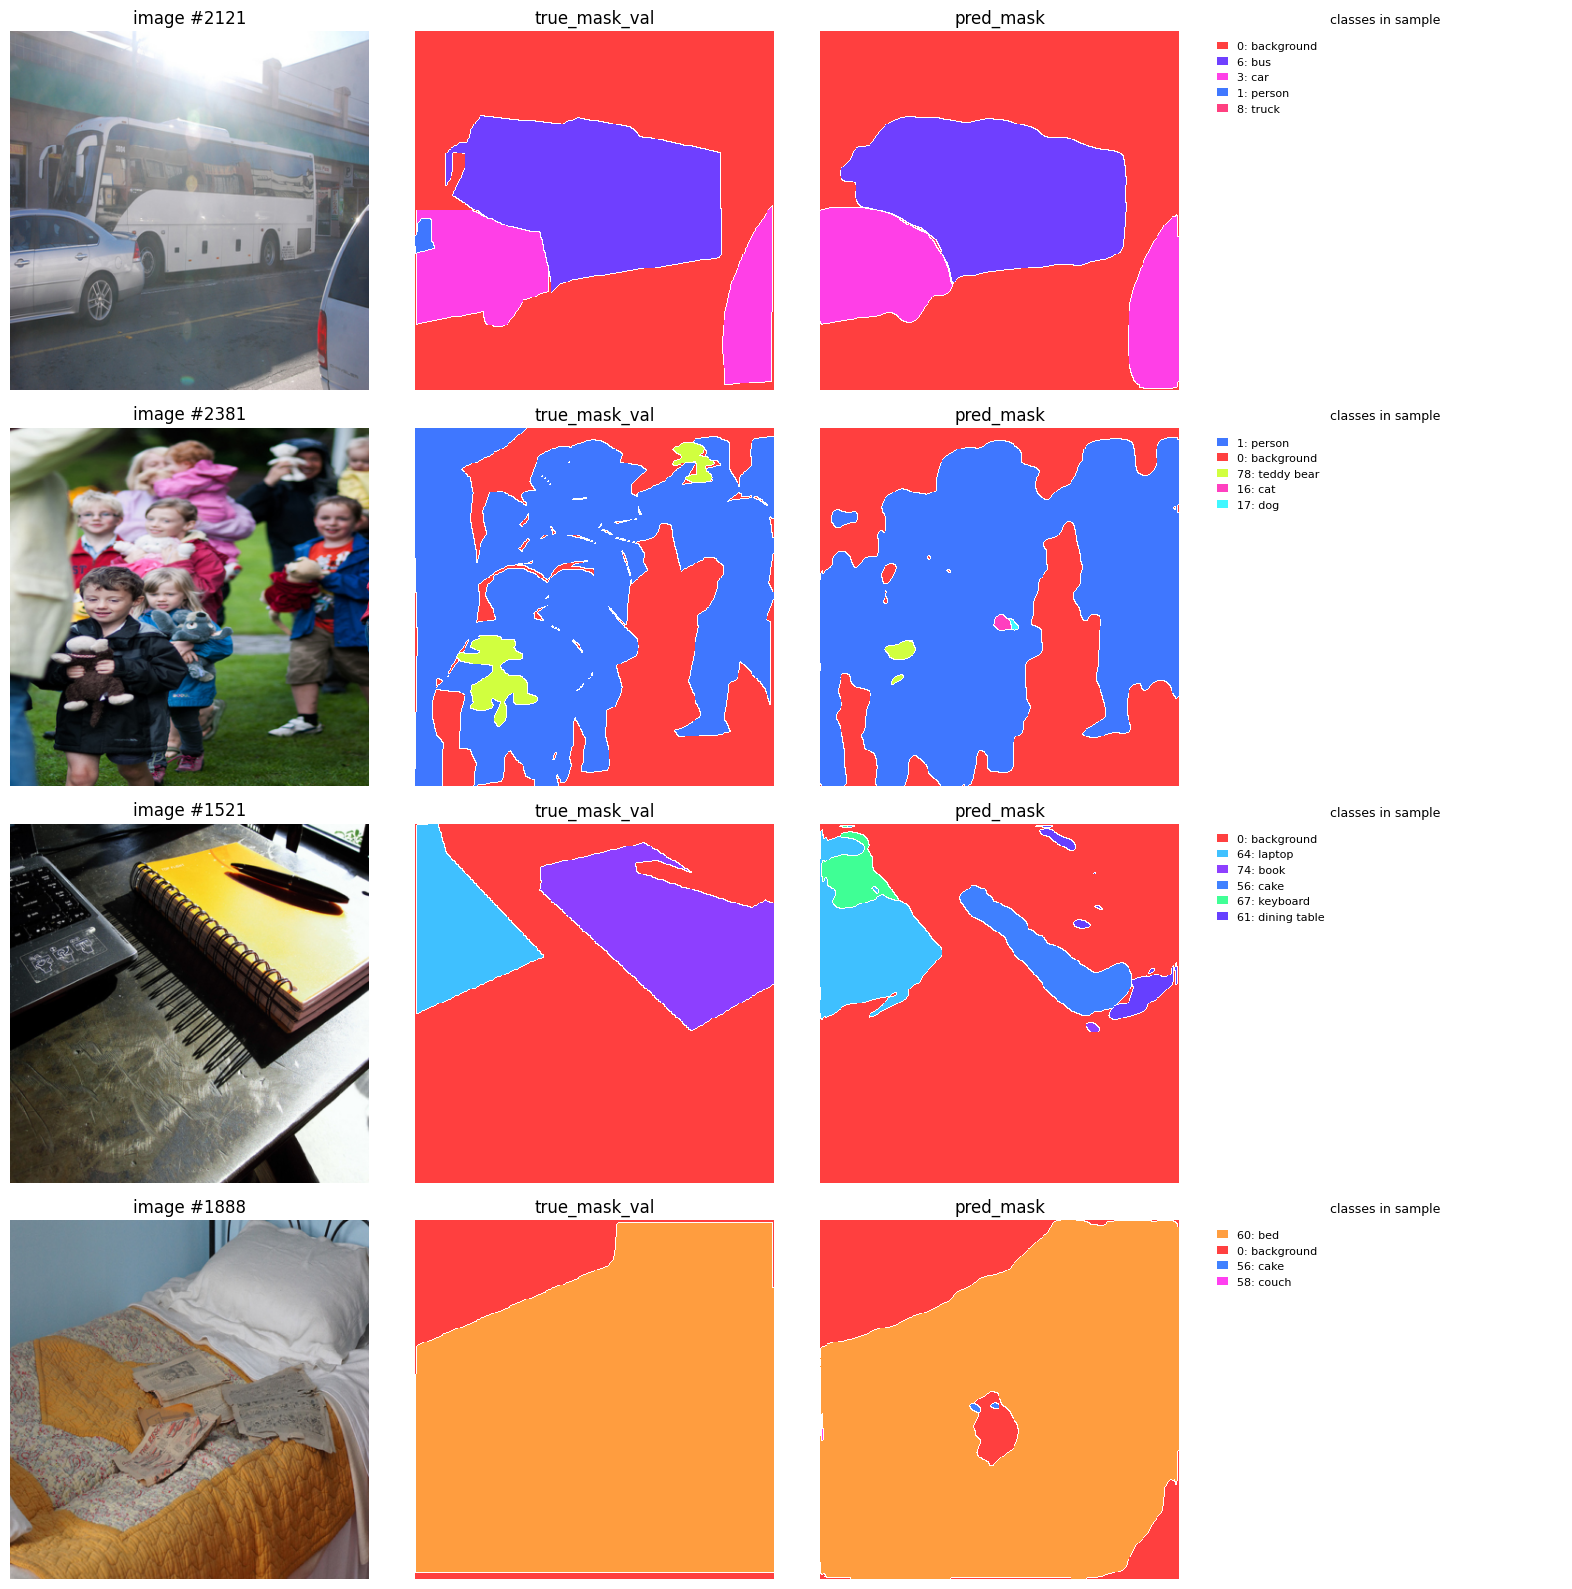

In [20]:
show_val_predictions_triplets(
    model=model,
    val_ds=val_ds,
    device=DEVICE,
    n_samples=4,
    seed=13,
    ignore_index=IGNORE_INDEX,
)

## Получение метрик 

In [16]:
@torch.no_grad()
def per_class_iou(
    model,
    loader,
    device,
    class_names,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    param_dtype = next(model.parameters()).dtype

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        if param_dtype in (torch.float16, torch.bfloat16):
            images = images.to(dtype=param_dtype)
        # if is_half_model:
        #     images = images.half()

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

In [17]:
rows, miou_present = per_class_iou(baseline, val_loader, DEVICE, val_ds.class_names, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
print("mIoU (only present classes):", round(miou_present, 4))

for r in rows:
    print(f"{r['class_id']:2d} {r['class_name']:12s} IoU={r['iou']:.3f} present={r['present_in_val']}")


mIoU (only present classes): 0.4525
 0 background   IoU=0.874 present=True
 1 person       IoU=0.769 present=True
 2 bicycle      IoU=0.516 present=True
 3 car          IoU=0.451 present=True
 4 motorcycle   IoU=0.681 present=True
 5 airplane     IoU=0.640 present=True
 6 bus          IoU=0.639 present=True
 7 train        IoU=0.635 present=True
 8 truck        IoU=0.376 present=True
 9 boat         IoU=0.420 present=True
10 traffic light IoU=0.488 present=True
11 fire hydrant IoU=0.738 present=True
12 stop sign    IoU=0.823 present=True
13 parking meter IoU=0.641 present=True
14 bench        IoU=0.336 present=True
15 bird         IoU=0.689 present=True
16 cat          IoU=0.766 present=True
17 dog          IoU=0.664 present=True
18 horse        IoU=0.609 present=True
19 sheep        IoU=0.644 present=True
20 cow          IoU=0.607 present=True
21 elephant     IoU=0.814 present=True
22 bear         IoU=0.808 present=True
23 zebra        IoU=0.864 present=True
24 giraffe      IoU=0.773 